# Investment Portfolio Analysis & Construction

## Composition & Market Outlook 
| Ticker | Name | Composition | Market Outlook |
|--------|------|-------------|----------------|
| **VOO** | Vanguard S&P 500 | Tracks the 500 largest US companies by market cap. Top holdings: Apple, Microsoft, Nvidia, Amazon, Meta. ~30% in tech, rest spread across healthcare, financials, consumer. | US large-caps benefit from resilient corporate earnings and the start of the Fed rate-cutting cycle (first cut Sep 2024). AI-driven capex from mega-caps supports continued growth. |
| **URTH** | iShares MSCI World | Tracks large/mid-cap stocks across 23 developed markets. ~70% US, rest in Japan, UK, Canada, Europe. Effectively a more diversified version of VOO. | Global developed-market recovery underway as inflation cools across the US and Europe. Weaker USD from rate cuts could lift non-US holdings when translated back. |
| **EWM** | iShares MSCI Malaysia | Broad exposure to Malaysian equities — banks (Maybank, CIMB), plantations (Sime Darby), telecoms, utilities. Heavily financials-weighted. | Malaysia benefits from China+1 supply chain diversification — FDI into Penang semiconductor corridor. Ringgit strengthening as Fed cuts narrow the rate differential. |
| **EWJ** | iShares MSCI Japan | Large/mid-cap Japanese equities — Toyota, Sony, Mitsubishi, Keyence. Mix of autos, industrials, tech, financials. | BOJ ended negative rates in March 2024 — signals confidence in the economy. Corporate governance reforms (Tokyo Stock Exchange push for higher ROE) driving re-rating of Japanese equities. Weak yen boosts exporters. |
| **GLD** | SPDR Gold Shares | Tracks the spot price of gold bullion. No equity exposure — purely a commodity play. | Gold hit record highs in 2024, driven by central bank buying (China, India), geopolitical hedging (Ukraine, Middle East), and anticipated Fed rate cuts which lower the opportunity cost of holding gold. |
| **QQQ** | Invesco QQQ Trust | Tracks the Nasdaq-100: the 100 largest non-financial Nasdaq-listed companies. ~60% in mega-cap tech (Apple, Nvidia, Microsoft, Broadcom, Meta). | AI infrastructure buildout is the dominant theme — Nvidia data center revenue tripled YoY. Hyperscaler capex from Microsoft, Google, Amazon flowing to semiconductor and cloud names in the index. |
| **IWM** | iShares Russell 2000 | Tracks the 2,000 smallest stocks in the Russell 3000. Broad sector exposure — industrials, healthcare, financials, tech. More domestically oriented than large-caps. | Small-caps historically outperform early in rate-cutting cycles as cheaper borrowing lifts smaller, more leveraged companies. Valuations are at multi-decade discounts relative to large-caps. |
| **MCHI** | iShares MSCI China | Large/mid-cap Chinese equities — Tencent, Alibaba, Meituan, PDD, JD.com. Heavy internet/consumer discretionary exposure. | Sentiment remains challenged — property sector deleveraging, weak consumer confidence, and US-China tensions weigh on valuations. However, stocks trade at deep discounts (MSCI China P/E ~10x vs S&P 500 ~21x), creating a contrarian case if stimulus materialises. |




In [171]:
import numpy as np 
import pandas as pd 
import yfinance as yf 
import matplotlib.pyplot as plt 
import statsmodels.api as sm
from scipy.optimize import minimize
import os

# Output directory
OUT_DIR = os.path.join(os.getcwd(), 'out')
os.makedirs(OUT_DIR, exist_ok=True)



tickers = ["VOO", "URTH", "EWM", "EWJ", "GLD", "QQQ", "IWM", "MCHI"]
names = {
    'VOO': 'Vanguard S&P 500', 'URTH': 'iShares MSCI World',
    'EWM': 'iShares MSCI Malaysia', 'EWJ': 'iShares MSCI Japan',
    'GLD': 'SPDR Gold Shares', 'QQQ': 'Invesco QQQ Trust',
    'IWM': 'iShares Russell 2000', 'MCHI': 'iShares MSCI China'
}

# Assume the risk-free rate is 4%
rf = 0.04

data = yf.download(tickers, start="2019-01-01", end="2024-12-31", auto_adjust=True)["Close"]
data = data.dropna()

data.tail()

[*********************100%***********************]  8 of 8 completed


Ticker,EWJ,EWM,GLD,IWM,MCHI,QQQ,URTH,VOO
Date,,,,,,,,
2024-12-23,63.577255,22.781874,240.960007,218.558975,46.261768,520.231567,154.943359,540.541138
2024-12-24,63.539005,23.013161,241.440002,220.513474,46.672638,527.285828,156.291992,546.102722
2024-12-26,64.275276,23.302273,243.070007,222.773972,46.790031,526.927551,156.577469,546.092834
2024-12-27,64.762939,23.427553,241.399994,219.526352,46.437859,519.923157,155.140259,540.432434
2024-12-30,64.217911,23.639568,240.630005,217.838379,45.929165,513.008179,153.683334,534.416443


## 1. Return & Risk Analysis
Determine each asset's standalone attractiveness using : Return, Risk and Sharpe Ratio. All annualized.



In [172]:
daily_returns = data.pct_change().dropna()

mean = daily_returns.mean()
sd = daily_returns.std()

annual_return = mean * 252
annual_volatility = sd * np.sqrt(252)
sharpe_ratios = (annual_return - rf) / annual_volatility

best_individual = sharpe_ratios.idxmax()
best_sr = sharpe_ratios.max()
print(f"Best individual Sharpe: {best_individual} ({best_sr:.3f}) — Section 4 portfolio must beat this to justify multi-asset construction")

summary = pd.DataFrame({
    "Annualised Return" : annual_return,
    "Annualised Volatility" : annual_volatility,
    "Sharpe Ratio" : sharpe_ratios
})

summary

Best individual Sharpe: QQQ (0.811) — Section 4 portfolio must beat this to justify multi-asset construction


,Annualised Return,Annualised Volatility,Sharpe Ratio
Ticker,,,
EWJ,0.080246,0.179728,0.223929
EWM,0.017993,0.169303,-0.129983
GLD,0.125640,0.149518,0.572773
IWM,0.129129,0.258254,0.345122
MCHI,0.046650,0.303857,0.021884
QQQ,0.237272,0.243364,0.810603
URTH,0.150171,0.192157,0.573340
VOO,0.179666,0.200997,0.694869


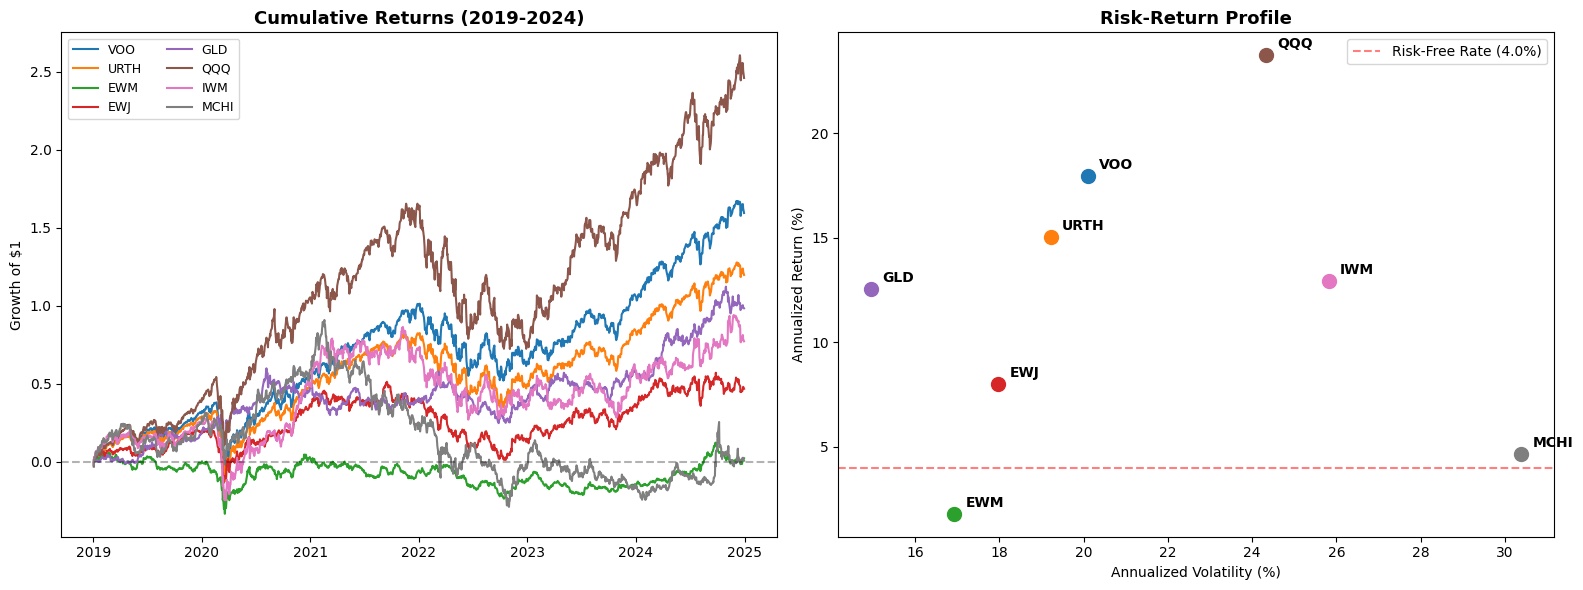

In [173]:
cum_returns = (1+daily_returns).cumprod() - 1

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Cumulative returns
for t in tickers:
    axes[0].plot(cum_returns.index, cum_returns[t], label=f'{t}', linewidth=1.5)
axes[0].set_title('Cumulative Returns (2019-2024)', fontweight='bold', fontsize=13)
axes[0].set_ylabel('Growth of $1')
axes[0].legend(fontsize=9, ncol=2)
axes[0].axhline(y=0, color='black', linestyle='--', alpha=0.3)

# Risk-return scatter
for t in tickers:
    axes[1].scatter(annual_volatility[t]*100, annual_return[t]*100, s=100, zorder=5)
    axes[1].annotate(t, (annual_volatility[t]*100, annual_return[t]*100),
                     textcoords="offset points", xytext=(8, 5), fontsize=10, fontweight='bold')
axes[1].set_xlabel('Annualized Volatility (%)')
axes[1].set_ylabel('Annualized Return (%)')
axes[1].set_title('Risk-Return Profile', fontweight='bold', fontsize=13)
axes[1].axhline(y=rf*100, color='red', linestyle='--', alpha=0.5, label=f'Risk-Free Rate ({rf*100}%)')
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'risk_return_profile.png'), dpi=150, bbox_inches='tight')
plt.show()

### Key Findings:
1. QQQ has the highest return but high volatility — it dominates on Sharpe among individual assets
2. GLD has moderate return with moderate volatility
   → If GLD's correlation with QQQ is low, it can be a diversifier (confirmed in Section 2)

## 2. Correlation & Diversification Analysis

Determine if assets can be *combined* to reduce portfolio volatility.

`σ_portfolio² = w₁²σ₁² + w₂²σ₂² + 2·w₁·w₂·σ₁·σ₂·ρ₁₂`

we look for assets with low correlation (close to 0 or negative)

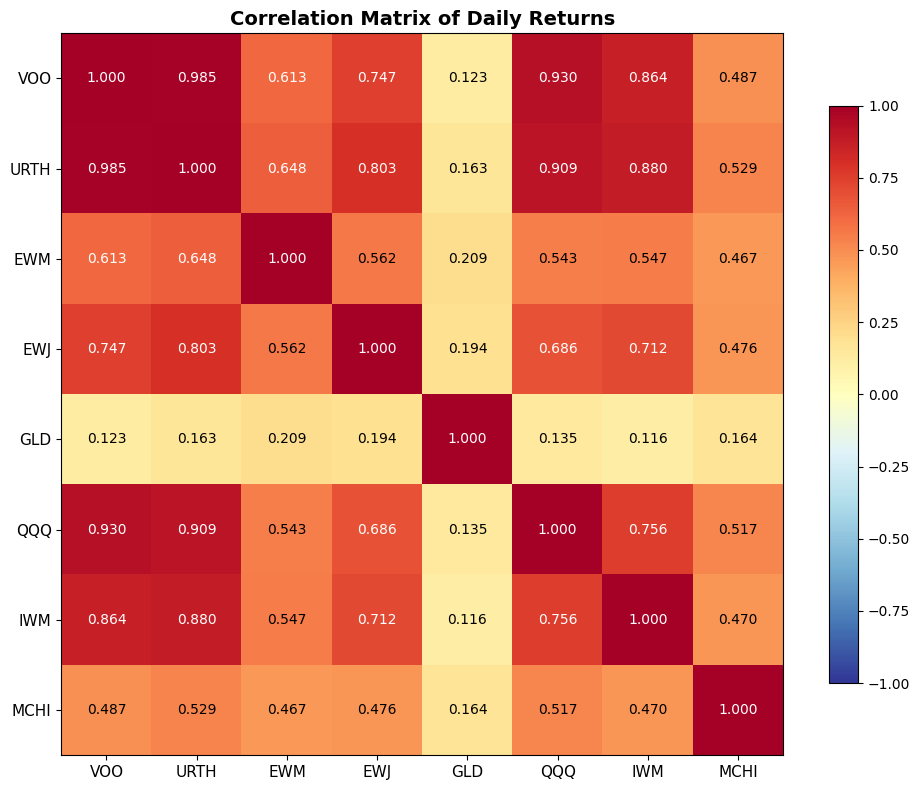


Key Diversification Insights:
  - QQQ-GLD correlation: 0.135 → key pair (QQQ is highest-return asset from Section 1)
  - Lowest overall: MCHI-GLD (0.164) — but MCHI has negative returns, low correlation alone isn't useful
  - Highest correlation: VOO-URTH (0.985) → near-redundant


In [174]:
# Correlation Matrix
corr_matrix = daily_returns[tickers].corr()

# Draw Correlation Matrix as Heat Map
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr_matrix.values, cmap='RdYlBu_r', vmin=-1, vmax=1)

ax.set_xticks(range(len(tickers)))
ax.set_yticks(range(len(tickers)))
ax.set_xticklabels(tickers, fontsize=11)
ax.set_yticklabels(tickers, fontsize=11)

for i in range(len(tickers)):
    for j in range(len(tickers)):
        ax.text(j, i, f'{corr_matrix.values[i, j]:.3f}',
                ha='center', va='center', fontsize=10,
                color='white' if abs(corr_matrix.values[i, j]) > 0.6 else 'black')

plt.colorbar(im, ax=ax, shrink=0.8)
ax.set_title('Correlation Matrix of Daily Returns', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'correlation_matrix.png'), dpi=150, bbox_inches='tight')
plt.show()

print("\nKey Diversification Insights:")
print(f"  - QQQ-GLD correlation: {corr_matrix.loc['QQQ','GLD']:.3f} → key pair (QQQ is highest-return asset from Section 1)")
print(f"  - Lowest overall: MCHI-GLD ({corr_matrix.loc['MCHI','GLD']:.3f}) — but MCHI has negative returns, low correlation alone isn't useful")
print(f"  - Highest correlation: VOO-URTH ({corr_matrix.loc['VOO','URTH']:.3f}) → near-redundant")

### Key Findings :

1. GLD has near-zero correlation with QQQ. We confirm that GLD can be used as diversifier for QQQ
2. US equity ETFs (VOO, URTH, QQQ, IWM) are correlated 0.8-0.95. Holding mutliple US equity adds little value to diversification.
3. MCHI has low correlation with most assets but negative returns. Unattractive


## 3. Beta Estimation via Linear Regression

Decompose each asset's total risk into two components:
- **Systematic risk (B)**
- **Idiosyncratic risk (e)**

**The regression model**:

`R_asset - Rf = α + β × (R_market - Rf) + ε`

**After regression, we compare actual vs required return using CAPM**:

`Required Return = Rf + β × (R_market - Rf)`

note that actual return - required return = alpha. Hence, we look for assets that outperforms what the market pays for its level of risk ( positive alpha )




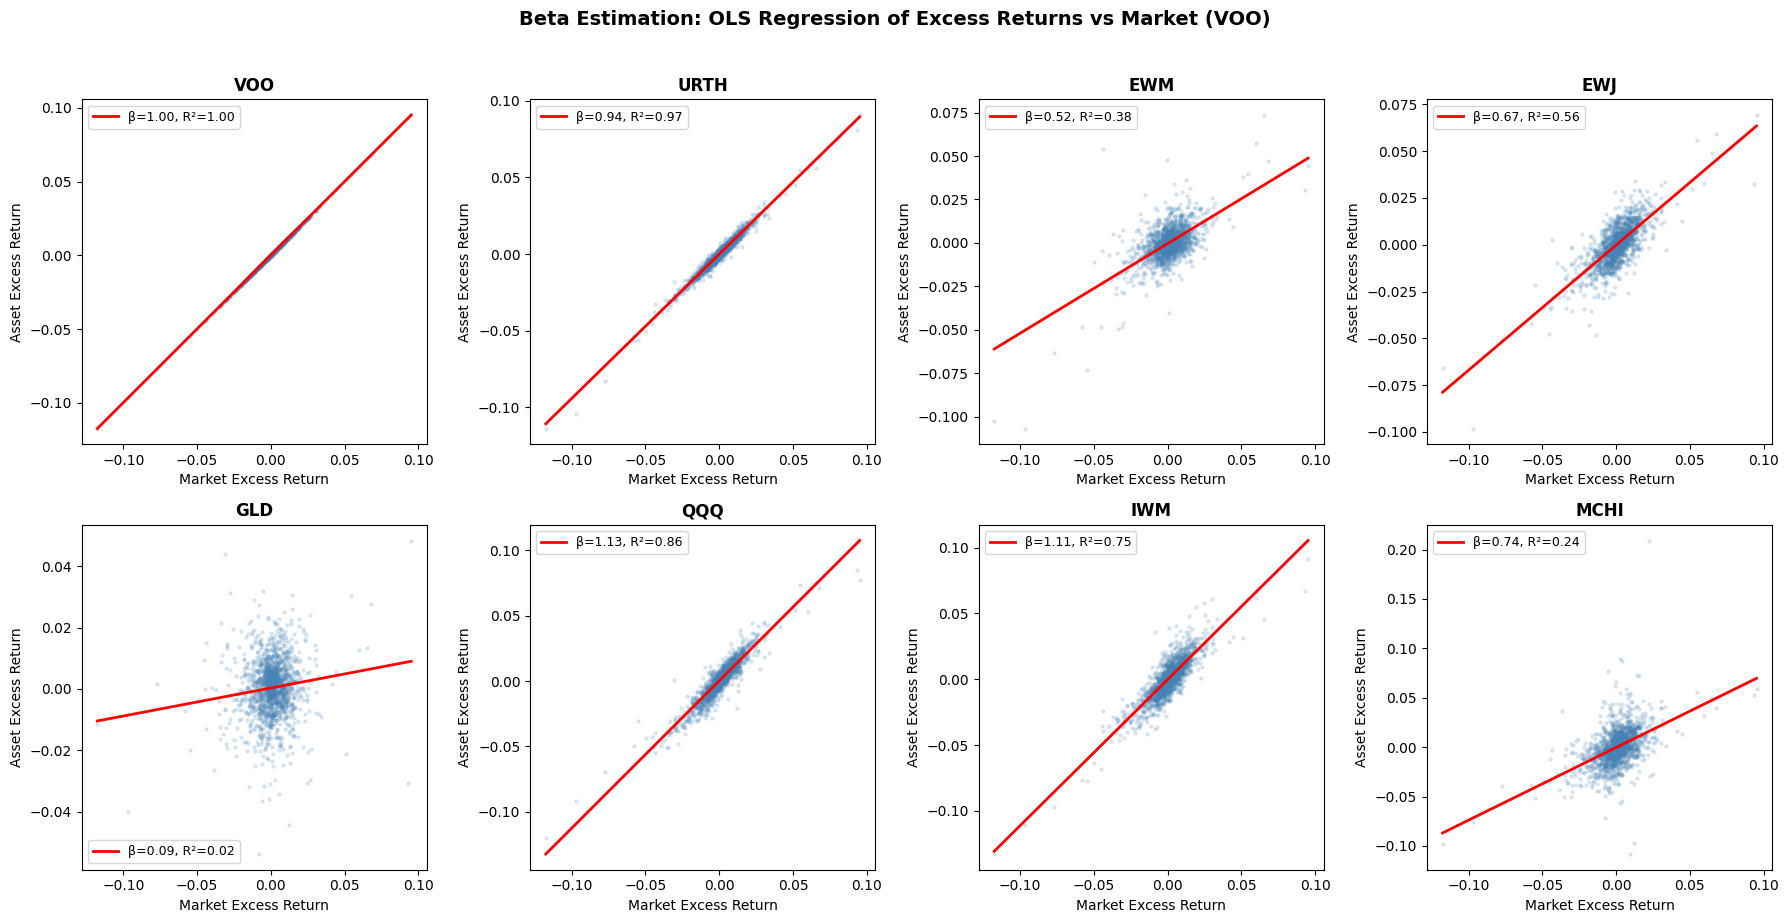

CAPM BETA ESTIMATION RESULTS


,Beta (b),"Alpha (a), annualized)",R-squared,CAPM Expected Return (%),Actual Return (%)
VOO,1.000000,0.00%,1.000,17.97,17.97
URTH,0.942059,-2.14%,0.971,17.16,15.02
EWM,0.516057,-9.41%,0.375,11.21,1.80
EWJ,0.668389,-5.31%,0.559,13.34,8.02
GLD,0.091434,7.29%,0.015,5.28,12.56
QQQ,1.125576,4.01%,0.864,19.72,23.73
IWM,1.109779,-6.59%,0.746,19.50,12.91
MCHI,0.735836,-9.61%,0.237,14.28,4.66


In [175]:
# Beta estimation via OLS regression against Market ( VOO as proxy )
market_excess = daily_returns['VOO'] - rf/252

betas = {}
alphas = {}
r_squared = {}
capm_expected = {}

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

for idx, ticker in enumerate(tickers):
    
    asset_excess = daily_returns[ticker] - rf/252
    
    X = sm.add_constant(market_excess)
    
    model = sm.OLS(asset_excess, X).fit()
    
    betas[ticker] = model.params.iloc[1]
    alphas[ticker] = model.params.iloc[0] * 252  # Annualize alpha
    r_squared[ticker] = model.rsquared
    
    # CAPM expected return: E(Ri) = Rf + Beta * (E(Rm) - Rf)
    market_premium = annual_return['VOO'] - rf
    capm_expected[ticker] = rf + betas[ticker] * market_premium
    
    # Scatter plot
    ax = axes[idx]
    ax.scatter(market_excess.values, asset_excess.values, alpha=0.15, s=5, color='steelblue')
    x_line = np.linspace(market_excess.min(), market_excess.max(), 100)
    y_line = model.params.iloc[0] + model.params.iloc[1] * x_line
    ax.plot(x_line, y_line, 'r-', linewidth=2,
            label=f'β={betas[ticker]:.2f}, R²={r_squared[ticker]:.2f}')
    ax.set_title(f'{ticker}', fontweight='bold')
    ax.legend(fontsize=9)
    ax.set_xlabel('Market Excess Return')
    ax.set_ylabel('Asset Excess Return')

plt.suptitle('Beta Estimation: OLS Regression of Excess Returns vs Market (VOO)',
             fontweight='bold', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'beta_regression.png'), dpi=150, bbox_inches='tight')
plt.show()

betas_array = np.array([betas[t] for t in tickers])

# CAPM Summary
capm_df = pd.DataFrame({
    'Beta (b)': [betas[t] for t in tickers],
    'Alpha (a), annualized)': [f"{alphas[t]*100:.2f}%" for t in tickers],
    'R-squared': [f"{r_squared[t]:.3f}" for t in tickers],
    'CAPM Expected Return (%)': [f"{capm_expected[t]*100:.2f}" for t in tickers],
    'Actual Return (%)': [f"{annual_return[t]*100:.2f}" for t in tickers]
}, index=tickers)

print("=" * 80)
print("CAPM BETA ESTIMATION RESULTS")
print("=" * 80)
capm_df

### Key Findings:
1. GLD's near-zero beta (0.091) means adding it to a portfolio reduces systematic risk without proportionally reducing return. Assumption of an optimum 2-asset portfolio of QQQ and GLD should hold: GLD provides alpha with no beta cost.

## 4. Mean-Variance Optimization & Efficient Frontier

Find the portfolio weights that **maximize Sharpe ratio** ( Section 1). The optimizer uses the **covariance matrix**, which encodes all the return, volatility, and correlation information ( Section 2).

We use Monte Carlo simulation to randomly generate 15,000 portfolios and map the feasible risk-return space. We maximise Sharpe ratio using SLSQP constrained optimisation to return:
1. **Max Sharpe Portfolio** — the weight combination with the best return per unit of total risk
2. **Min Variance Portfolio** — the weight combination with the lowest total volatility (most conservative)
3. **Capital Market Line (CML)** — the line from Rf through the Max Sharpe point. Any portfolio on this line is achievable by mixing the optimal portfolio with cash. Nothing *above* the CML is achievable without leverage.

**Conditions**:
1. Portfolio Sharpe must beat `best_individual` from section 1 — otherwise multi-asset construction adds no value
2. The optimizer should select QQQ + GLD — confirming section 2's correlation prediction
3. Portfolio beta (using Section 3's `betas_array`) should be low — confirming GLD dilutes QQQ's beta

In [176]:
# Covariance matrix (annualized)
cov_matrix = daily_returns[tickers].cov() * 252
mean_returns = annual_return[tickers].values

n_assets = len(tickers)

def portfolio_performance(weights, mean_returns, cov_matrix):
    ret = np.dot(weights, mean_returns)
    vol = np.sqrt(np.dot(weights.T, np.dot(cov_matrix.values, weights)))
    return ret, vol

def neg_sharpe(weights, mean_returns, cov_matrix, rf):
    ret, vol = portfolio_performance(weights, mean_returns, cov_matrix)
    return -(ret - rf) / vol

# Constraints: weights sum to 1, each weight between 0 and 1 (long only)
constraints = ({'type': 'eq', 'fun': lambda w: np.sum(w) - 1})
bounds = tuple((0, 1) for _ in range(n_assets))

# Monte Carlo simulation for efficient frontier visualization
n_portfolios = 15000
results = np.zeros((3, n_portfolios))
weights_record = []

np.random.seed(42)
for i in range(n_portfolios):
    w = np.random.dirichlet(np.ones(n_assets))
    weights_record.append(w)
    ret, vol = portfolio_performance(w, mean_returns, cov_matrix)
    results[0, i] = vol * 100
    results[1, i] = ret * 100
    results[2, i] = (ret - rf) / vol

# Optimal portfolio (max Sharpe)
init_guess = np.array([1/n_assets] * n_assets)
opt_sharpe = minimize(neg_sharpe, init_guess, args=(mean_returns, cov_matrix, rf),
                      method='SLSQP', bounds=bounds, constraints=constraints)
opt_ret, opt_vol = portfolio_performance(opt_sharpe.x, mean_returns, cov_matrix)

# Minimum variance portfolio
def portfolio_vol(weights, cov_matrix):
    return np.sqrt(np.dot(weights.T, np.dot(cov_matrix.values, weights)))

min_var = minimize(portfolio_vol, init_guess, args=(cov_matrix,),
                   method='SLSQP', bounds=bounds, constraints=constraints)
mv_ret, mv_vol = portfolio_performance(min_var.x, mean_returns, cov_matrix)

opt_sr   = (opt_ret - rf) / opt_vol
opt_beta = np.dot(opt_sharpe.x, betas_array)

print(f"Optimal Sharpe Portfolio: Return={opt_ret*100:.2f}%, Vol={opt_vol*100:.2f}%, Sharpe={opt_sr:.3f}")
print(f"Min Variance Portfolio:   Return={mv_ret*100:.2f}%, Vol={mv_vol*100:.2f}%, Sharpe={(mv_ret-rf)/mv_vol:.3f}")

print(f"\nValidation against Section 1-3 predictions:")
top_holdings = pd.Series(opt_sharpe.x, index=tickers).nlargest(2)
print(f"  1. Portfolio Sharpe ({opt_sr:.3f}) vs {best_individual} ({best_sr:.3f}) → {'PASS' if opt_sr > best_sr else 'FAIL'}")
print(f"  2. Top holdings: {', '.join([f'{t} ({w*100:.1f}%)' for t, w in top_holdings.items()])}")
print(f"  3. Portfolio beta = {opt_beta:.3f} → crash -10% implies ≈{opt_beta*10:.1f}% vs QQQ alone ≈{betas['QQQ']*10:.1f}%")

Optimal Sharpe Portfolio: Return=18.07%, Vol=15.03%, Sharpe=0.936
Min Variance Portfolio:   Return=9.27%, Vol=11.86%, Sharpe=0.444

Validation against Section 1-3 predictions:
  1. Portfolio Sharpe (0.936) vs QQQ (0.811) → PASS
  2. Top holdings: GLD (50.7%), QQQ (49.3%)
  3. Portfolio beta = 0.601 → crash -10% implies ≈6.0% vs QQQ alone ≈11.3%


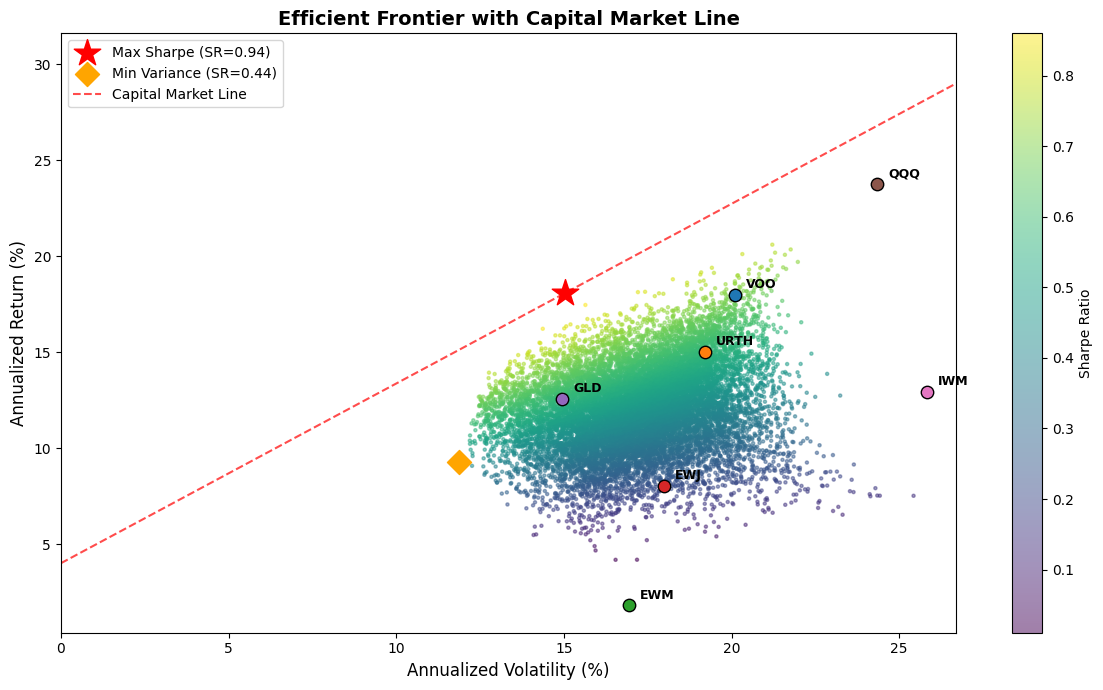

In [177]:
# Plot efficient frontier
fig, ax = plt.subplots(figsize=(12, 7))

scatter = ax.scatter(results[0], results[1], c=results[2], cmap='viridis',
                     marker='o', s=5, alpha=0.5)
plt.colorbar(scatter, ax=ax, label='Sharpe Ratio')

# Optimal portfolio
ax.scatter(opt_vol*100, opt_ret*100, marker='*', color='red', s=400, zorder=5,
           label=f'Max Sharpe (SR={((opt_ret-rf)/opt_vol):.2f})')
# Min variance
ax.scatter(mv_vol*100, mv_ret*100, marker='D', color='orange', s=150, zorder=5,
           label=f'Min Variance (SR={((mv_ret-rf)/mv_vol):.2f})')

# Individual assets
for t in tickers:
    ax.scatter(annual_volatility[t]*100, annual_return[t]*100, s=80, zorder=5,
               edgecolors='black', linewidth=1)
    ax.annotate(t, (annual_volatility[t]*100, annual_return[t]*100),
                textcoords="offset points", xytext=(8, 5), fontsize=9, fontweight='bold')

# Capital Market Line
cml_x = np.linspace(0, max(results[0])*1.1, 100)
cml_y = rf*100 + ((opt_ret-rf)/opt_vol) * cml_x
ax.plot(cml_x, cml_y, 'r--', linewidth=1.5, alpha=0.7, label='Capital Market Line')

ax.set_xlabel('Annualized Volatility (%)', fontsize=12)
ax.set_ylabel('Annualized Return (%)', fontsize=12)
ax.set_title('Efficient Frontier with Capital Market Line', fontweight='bold', fontsize=14)
ax.legend(fontsize=10)
ax.set_xlim(0, max(results[0])*1.05)

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'efficient_frontier.png'), dpi=150, bbox_inches='tight')
plt.show()

OPTIMAL PORTFOLIO ALLOCATION (Maximum Sharpe Ratio)
  GLD    (SPDR Gold Shares         ):  50.72%
  QQQ    (Invesco QQQ Trust        ):  49.28%

  Expected Return:  18.07%
  Expected Vol:     15.03%
  Sharpe Ratio:     0.936


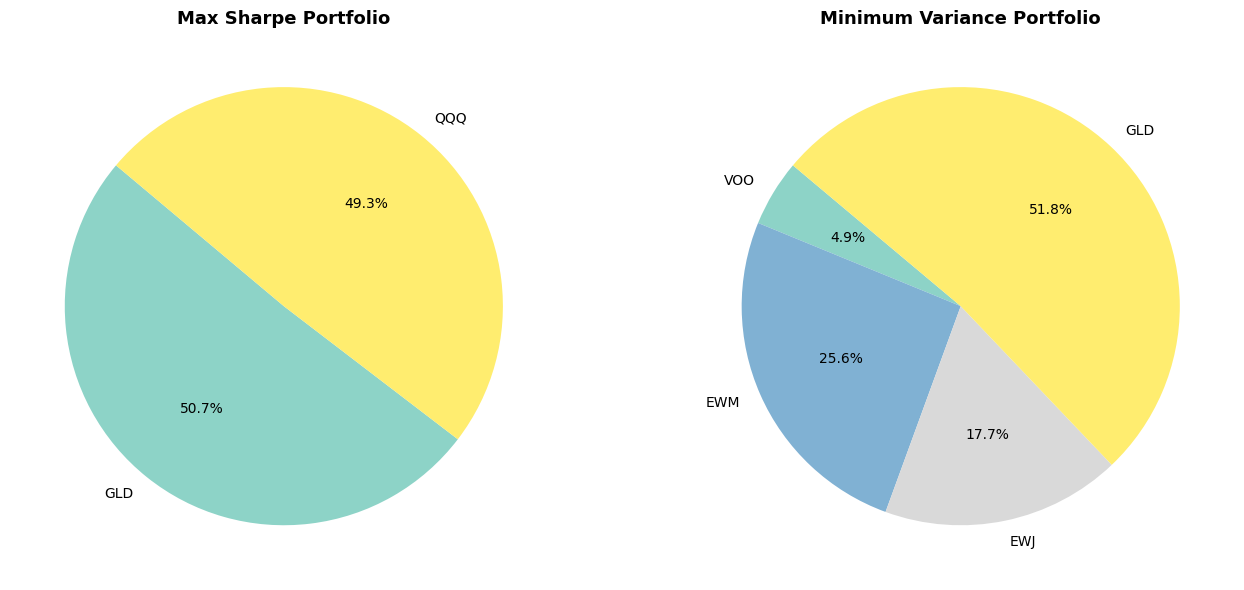


MINIMUM VARIANCE PORTFOLIO ALLOCATION
  VOO    (Vanguard S&P 500         ):   4.91%
  EWM    (iShares MSCI Malaysia    ):  25.62%
  EWJ    (iShares MSCI Japan       ):  17.68%
  GLD    (SPDR Gold Shares         ):  51.78%

  Expected Return:  9.27%
  Expected Vol:     11.86%
  Sharpe Ratio:     0.444


In [178]:
# Display optimal portfolio weights
print("=" * 60)
print("OPTIMAL PORTFOLIO ALLOCATION (Maximum Sharpe Ratio)")
print("=" * 60)

opt_weights = pd.Series(opt_sharpe.x, index=tickers)
opt_weights_pct = (opt_weights * 100).round(2)

for t in tickers:
    if opt_weights_pct[t] > 0.5:
        print(f"  {t:6s} ({names[t]:25s}): {opt_weights_pct[t]:6.2f}%")

print(f"\n  Expected Return:  {opt_ret*100:.2f}%")
print(f"  Expected Vol:     {opt_vol*100:.2f}%")
print(f"  Sharpe Ratio:     {(opt_ret-rf)/opt_vol:.3f}")

# Pie chart
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Max Sharpe
significant = opt_weights[opt_weights > 0.01]
colors = plt.cm.Set3(np.linspace(0, 1, len(significant)))
axes[0].pie(significant.values, labels=significant.index, autopct='%1.1f%%',
            colors=colors, startangle=140)
axes[0].set_title('Max Sharpe Portfolio', fontweight='bold', fontsize=13)

# Min Variance
mv_weights = pd.Series(min_var.x, index=tickers)
significant_mv = mv_weights[mv_weights > 0.01]
colors_mv = plt.cm.Set3(np.linspace(0, 1, len(significant_mv)))
axes[1].pie(significant_mv.values, labels=significant_mv.index, autopct='%1.1f%%',
            colors=colors_mv, startangle=140)
axes[1].set_title('Minimum Variance Portfolio', fontweight='bold', fontsize=13)

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'portfolio_allocation.png'), dpi=150, bbox_inches='tight')
plt.show()

print("\n" + "=" * 60)
print("MINIMUM VARIANCE PORTFOLIO ALLOCATION")
print("=" * 60)
for t in tickers:
    if mv_weights[t]*100 > 0.5:
        print(f"  {t:6s} ({names[t]:25s}): {mv_weights[t]*100:6.2f}%")
print(f"\n  Expected Return:  {mv_ret*100:.2f}%")
print(f"  Expected Vol:     {mv_vol*100:.2f}%")
print(f"  Sharpe Ratio:     {(mv_ret-rf)/mv_vol:.3f}")

### Key Findings:
1. Portfolio Sharpe beats the best individual asset — multi-asset construction adds value
2. Optimizer independently selected QQQ + GLD, confirming Section 2 (near-zero correlation) and Section 3 (GLD β ≈ 0 + positive alpha)
3. Portfolio β is significantly lower than QQQ's alone — GLD dilutes market exposure without sacrificing Sharpe

## 5. Beta-Constrained Optimization

Test whether explicitly constraining portfolio beta changes the Section 4 result.

**The question**: Section 4 showed the Max Sharpe portfolio naturally achieved β = 0.601. What if we *force* an even lower beta? How much Sharpe do we sacrifice per unit of beta reduction?

We use Section 3's `betas_array` as an explicit constraint: `Σ(wᵢ × βᵢ) ≤ cap`, sweeping caps from 0.05 → 1.1.

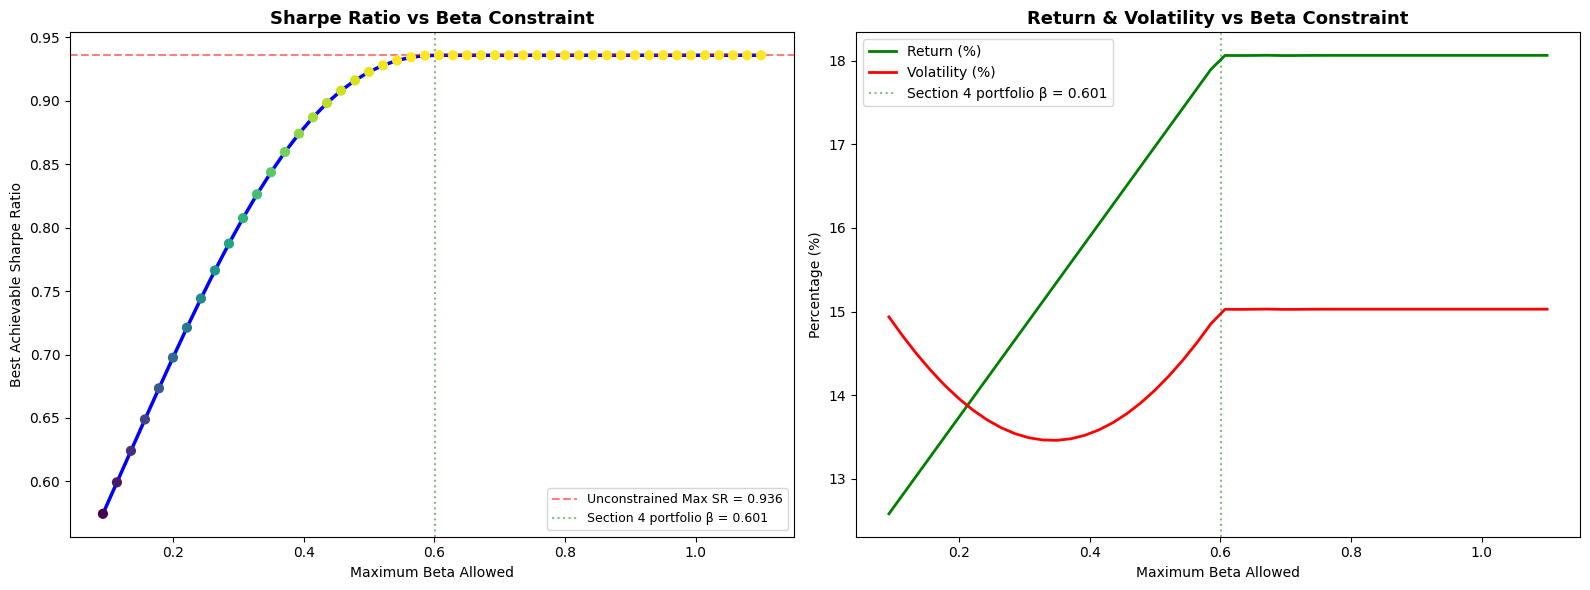

In [179]:
beta_caps = np.linspace(0.05, 1.1, 50)
sharpe_at_beta = []
ret_at_beta = []
vol_at_beta = []

for bc in beta_caps:
    cons_bc = [
        {'type': 'eq',  'fun': lambda w: np.sum(w) - 1},
        {'type': 'ineq','fun': lambda w, cap=bc: cap - np.dot(w, betas_array)}
    ]
    result = minimize(neg_sharpe, init_guess, args=(mean_returns, cov_matrix, rf),
                      method='SLSQP', bounds=bounds, constraints=cons_bc)
    if result.success:
        r, v = portfolio_performance(result.x, mean_returns, cov_matrix)
        sharpe_at_beta.append((r - rf) / v)
        ret_at_beta.append(r * 100)
        vol_at_beta.append(v * 100)
    else:
        sharpe_at_beta.append(np.nan)
        ret_at_beta.append(np.nan)
        vol_at_beta.append(np.nan)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].plot(beta_caps, sharpe_at_beta, 'b-', linewidth=2.5)
axes[0].scatter(beta_caps, sharpe_at_beta, c=sharpe_at_beta, cmap='viridis', s=40, zorder=5)
axes[0].axhline(y=opt_sr, color='red', linestyle='--', alpha=0.5,
                label=f'Unconstrained Max SR = {opt_sr:.3f}')
axes[0].axvline(x=opt_beta, color='green', linestyle=':', alpha=0.5,
                label=f'Section 4 portfolio β = {opt_beta:.3f}')
axes[0].set_xlabel('Maximum Beta Allowed')
axes[0].set_ylabel('Best Achievable Sharpe Ratio')
axes[0].set_title('Sharpe Ratio vs Beta Constraint', fontweight='bold', fontsize=13)
axes[0].legend(fontsize=9)

axes[1].plot(beta_caps, ret_at_beta, 'g-', linewidth=2, label='Return (%)')
axes[1].plot(beta_caps, vol_at_beta, 'r-', linewidth=2, label='Volatility (%)')
axes[1].axvline(x=opt_beta, color='green', linestyle=':', alpha=0.5,
                label=f'Section 4 portfolio β = {opt_beta:.3f}')
axes[1].set_xlabel('Maximum Beta Allowed')
axes[1].set_ylabel('Percentage (%)')
axes[1].set_title('Return & Volatility vs Beta Constraint', fontweight='bold', fontsize=13)
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'sharpe_vs_beta_tradeoff.png'), dpi=150, bbox_inches='tight')
plt.show()

### Key Findings:
1. The Section 4 portfolio already has a naturally low β — the constraint is not binding above the unconstrained optimum, so the Sharpe curve is perfectly flat in that region
2. Below the unconstrained β, Sharpe drops gradually — the cost of reducing market exposure accelerates the further you push β down
3. GLD's near-zero β (Section 3) acts as a built-in crash buffer; the optimizer already allocated the optimal amount in Section 4, making explicit β constraints redundant

## 6. Backtest & Performance Validation (In-Sample, 2019–2024)

Apply the Section 4 frozen weights to the same period used to fit them. This is **in-sample** — it confirms the optimization worked on training data, but does not prove out-of-sample generalization.

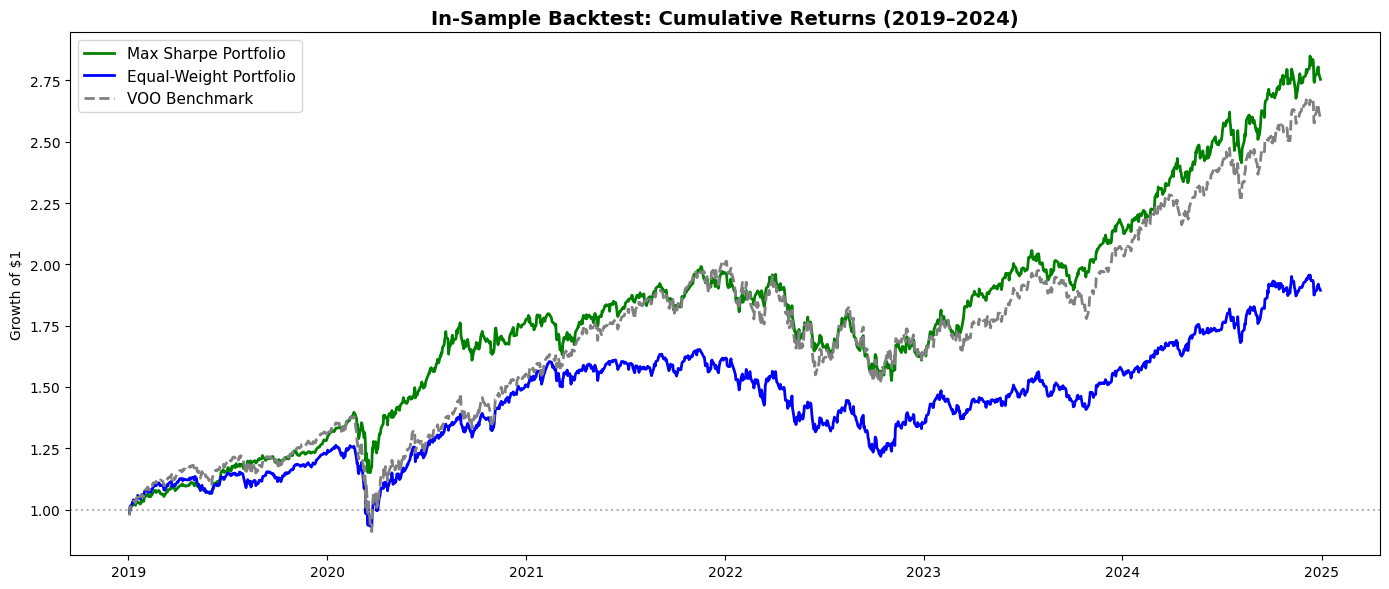

IN-SAMPLE BACKTEST RESULTS (2019–2024)


,Ann. Return (%),Ann. Vol (%),Sharpe,Beta,Max Drawdown (%),Total Return (%)
Strategy,,,,,,
Max Sharpe,18.07,15.03,0.936,0.601,-23.34,175.41
Equal-Weight,12.08,16.73,0.483,0.774,-26.35,89.43
VOO Benchmark,17.97,20.10,0.695,1.000,-33.99,159.46


In [180]:
eq_weights = np.array([1/n_assets] * n_assets)

opt_daily   = daily_returns[tickers].dot(opt_sharpe.x)
eq_daily    = daily_returns[tickers].dot(eq_weights)
bench_daily = daily_returns['VOO']

opt_cum   = (1 + opt_daily).cumprod()
eq_cum    = (1 + eq_daily).cumprod()
bench_cum = (1 + bench_daily).cumprod()

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(opt_cum.index, opt_cum, label='Max Sharpe Portfolio', linewidth=2, color='green')
ax.plot(eq_cum.index, eq_cum, label='Equal-Weight Portfolio', linewidth=2, color='blue')
ax.plot(bench_cum.index, bench_cum, label='VOO Benchmark', linewidth=2, color='gray', linestyle='--')
ax.axhline(y=1, color='black', linestyle=':', alpha=0.3)
ax.set_title('In-Sample Backtest: Cumulative Returns (2019–2024)', fontweight='bold', fontsize=14)
ax.set_ylabel('Growth of $1')
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'portfolio_backtest.png'), dpi=150, bbox_inches='tight')
plt.show()

def calc_metrics(returns, name, weights=None):
    ann_ret = returns.mean() * 252
    ann_vol = returns.std() * np.sqrt(252)
    sharpe  = (ann_ret - rf) / ann_vol
    cum     = (1 + returns).cumprod()
    max_dd  = (cum / cum.cummax() - 1).min()
    beta_val = np.dot(weights, betas_array) if weights is not None else betas['VOO']
    return {
        'Strategy':         name,
        'Ann. Return (%)':  round(ann_ret * 100, 2),
        'Ann. Vol (%)':     round(ann_vol * 100, 2),
        'Sharpe':           round(sharpe, 3),
        'Beta':             round(beta_val, 3),
        'Max Drawdown (%)': round(max_dd * 100, 2),
        'Total Return (%)': round((cum.iloc[-1] - 1) * 100, 2)
    }

comparison = pd.DataFrame([
    calc_metrics(opt_daily,   'Max Sharpe',    opt_sharpe.x),
    calc_metrics(eq_daily,    'Equal-Weight',  eq_weights),
    calc_metrics(bench_daily, 'VOO Benchmark', np.array([1 if t=='VOO' else 0 for t in tickers]))
]).set_index('Strategy')

print("IN-SAMPLE BACKTEST RESULTS (2019–2024)")
print("=" * 80)
comparison

**Key Findings:**
1. Max Sharpe outperforms both Equal-Weight and VOO on Sharpe and total return
2. Beta confirms crash protection: Max Sharpe β ≈ 0.60 vs VOO β = 1.00
3. This is in-sample — weights were optimized on this exact data, so outperformance is expected. Section 7 tests whether it holds on unseen data

## 7. NEW : Out-of-Sample Backtest (2025–2026)

Apply the same frozen Section 4 weights to completely unseen data. Unlike Section 6, the optimizer had **no information** about this period — any outperformance here is genuine.

We also track rolling 60-day beta to check whether Section 3's estimate holds out-of-sample.

[*********************100%***********************]  8 of 8 completed


Out-of-sample: 2025-01-02 to 2026-03-19 (302 trading days)
Frozen weights from Section 4: GLD 50.7%, QQQ 49.3%


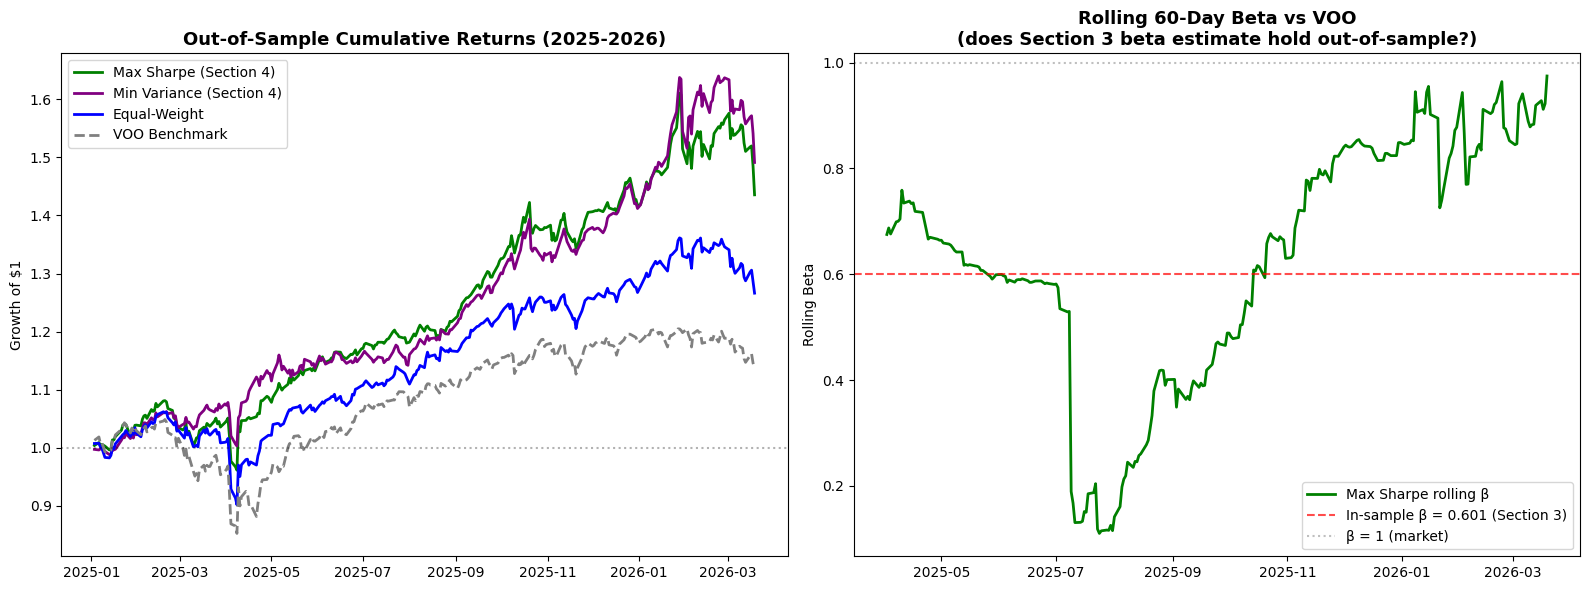

OUT-OF-SAMPLE PERFORMANCE (2025-2026)


,Ann. Return (%),Ann. Vol (%),Sharpe,Beta,Max Drawdown (%),Total Return (%)
Strategy,,,,,,
Max Sharpe (Section 4),31.72,17.53,1.581,0.601,-11.07,43.55
Min Variance (Section 4),34.71,16.41,1.872,0.347,-9.07,49.13
Equal-Weight,20.92,15.64,1.082,0.774,-15.08,26.63
VOO Benchmark,12.28,17.63,0.469,1.000,-18.69,13.73



In-sample Sharpe  (Section 6, 2019-2024): 0.936
Out-of-sample Sharpe (Section 7, 2025-2026): 1.581
Degradation: -0.645 — strategy held up out-of-sample


In [181]:
oos_data = yf.download(tickers, start="2025-01-01", end="2026-12-31", auto_adjust=True)["Close"]
oos_data = oos_data.dropna()
oos_returns = oos_data.pct_change().dropna()

print(f"Out-of-sample: {oos_data.index[0].strftime('%Y-%m-%d')} to {oos_data.index[-1].strftime('%Y-%m-%d')} ({len(oos_returns)} trading days)")
print(f"Frozen weights from Section 4: {', '.join([f'{t} {w*100:.1f}%' for t, w in zip(tickers, opt_sharpe.x) if w > 0.01])}")

oos_opt   = oos_returns[tickers].dot(opt_sharpe.x)
oos_mv    = oos_returns[tickers].dot(min_var.x)
oos_eq    = oos_returns[tickers].dot(eq_weights)
oos_bench = oos_returns['VOO']

oos_opt_cum   = (1 + oos_opt).cumprod()
oos_mv_cum    = (1 + oos_mv).cumprod()
oos_eq_cum    = (1 + oos_eq).cumprod()
oos_bench_cum = (1 + oos_bench).cumprod()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].plot(oos_opt_cum.index,   oos_opt_cum,   label='Max Sharpe (Section 4)',   linewidth=2, color='green')
axes[0].plot(oos_mv_cum.index,    oos_mv_cum,    label='Min Variance (Section 4)', linewidth=2, color='purple')
axes[0].plot(oos_eq_cum.index,    oos_eq_cum,    label='Equal-Weight',      linewidth=2, color='blue')
axes[0].plot(oos_bench_cum.index, oos_bench_cum, label='VOO Benchmark',     linewidth=2, color='gray', linestyle='--')
axes[0].axhline(y=1, color='black', linestyle=':', alpha=0.3)
axes[0].set_title('Out-of-Sample Cumulative Returns (2025-2026)', fontweight='bold', fontsize=13)
axes[0].set_ylabel('Growth of $1')
axes[0].legend(fontsize=10)

# Rolling 60-day beta
window = 60
rolling_beta = []
rolling_dates = []
for i in range(window, len(oos_returns)):
    w_ret = oos_returns.iloc[i-window:i]
    port_r = w_ret[tickers].dot(opt_sharpe.x)
    mkt_r  = w_ret['VOO']
    X = sm.add_constant(mkt_r)
    b = sm.OLS(port_r, X).fit().params.iloc[1]
    rolling_beta.append(b)
    rolling_dates.append(oos_returns.index[i])

axes[1].plot(rolling_dates, rolling_beta, color='green', linewidth=2, label='Max Sharpe rolling β')
axes[1].axhline(y=opt_beta, color='red', linestyle='--', alpha=0.7,
                label=f'In-sample β = {opt_beta:.3f} (Section 3)')
axes[1].axhline(y=1.0, color='gray', linestyle=':', alpha=0.5, label='β = 1 (market)')
axes[1].set_title('Rolling 60-Day Beta vs VOO\n(does Section 3 beta estimate hold out-of-sample?)', fontweight='bold', fontsize=13)
axes[1].set_ylabel('Rolling Beta')
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'oos_backtest.png'), dpi=150, bbox_inches='tight')
plt.show()

oos_comparison = pd.DataFrame([
    calc_metrics(oos_opt,   'Max Sharpe (Section 4)',   opt_sharpe.x),
    calc_metrics(oos_mv,    'Min Variance (Section 4)', min_var.x),
    calc_metrics(oos_eq,    'Equal-Weight',      eq_weights),
    calc_metrics(oos_bench, 'VOO Benchmark',     np.array([1 if t=='VOO' else 0 for t in tickers]))
]).set_index('Strategy')

print("OUT-OF-SAMPLE PERFORMANCE (2025-2026)")
print("=" * 80)
display(oos_comparison)

is_sharpe  = comparison.loc['Max Sharpe', 'Sharpe']
oos_sharpe = oos_comparison.loc['Max Sharpe (Section 4)', 'Sharpe']
print(f"\nIn-sample Sharpe  (Section 6, 2019-2024): {is_sharpe:.3f}")
print(f"Out-of-sample Sharpe (Section 7, 2025-2026): {oos_sharpe:.3f}")
print(f"Degradation: {is_sharpe - oos_sharpe:+.3f} — {'expected for unseen data' if oos_sharpe < is_sharpe else 'strategy held up out-of-sample'}")